# TEMA: INTERPOLACIÓN

<class 'numpy.ndarray'>


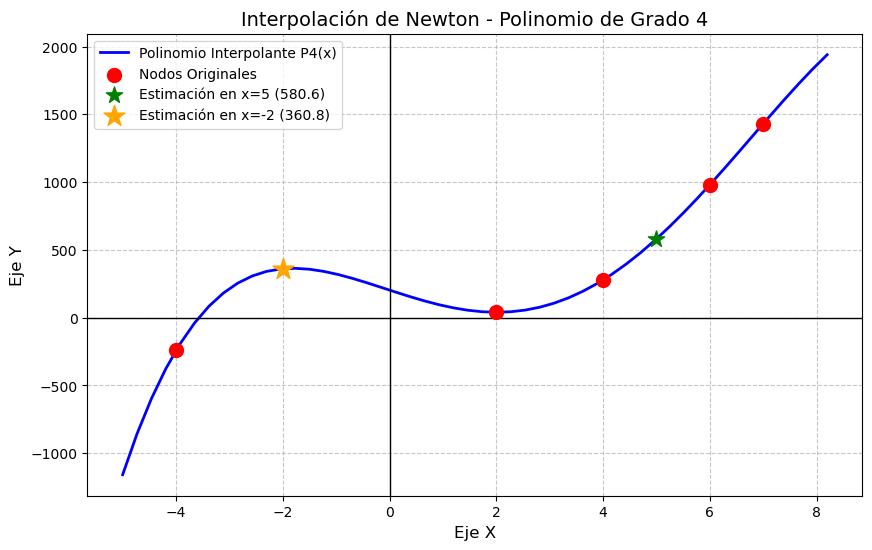

In [7]:
import numpy as np
import matplotlib.pyplot as pl

x_nodo = np.array([4,-4,7,6,2])
y_nodo = np.array([278,-242,1430,980,40])

def P4(x):      # Polinomio de grado 4 del apartado a
    termino_1 = 278
    diferencia_1 = 65*(x-4)
    diferencia_2 = 29*(x-4)*(x+4)
    diferencia_3 = 0.4*(x-4)*(x+4)*(x-7)
    diferencia_4 = 0.9*(x-4)*(x+4)*(x-7)*(x-6)
    return termino_1 + diferencia_1 + diferencia_2 + diferencia_3 - diferencia_4

x_curva = np.linspace(-5,8.200)
print(type(x_curva))
y_curva = P4(x_curva)

pl.figure(figsize=(10, 6))

pl.plot(x_curva, y_curva, label="Polinomio Interpolante P4(x)", color="blue", linewidth=2)

pl.scatter(x_nodo, y_nodo, color="red", s=100, zorder=5, label="Nodos Originales")

y_5 = P4(5)

pl.scatter(5, y_5, color="green", s=150, marker="*", zorder=6, label=f"Estimación en x=5 ({y_5:.1f})")

y_menos2 = P4(-2)

pl.scatter(-2, y_menos2, color="orange", s=250, marker="*", zorder=6, label=f"Estimación en x=-2 ({y_menos2:.1f})")

pl.title("Interpolación de Newton - Polinomio de Grado 4", fontsize=14)
pl.xlabel("Eje X", fontsize=12)
pl.ylabel("Eje Y", fontsize=12)

pl.axhline(0,color='black', linewidth=1)
pl.axvline(0,color='black', linewidth=1)

pl.grid(True, linestyle="--", alpha=0.7)
pl.legend(loc="upper left")

pl.show()

# 2) Método de Newton

In [1]:
import numpy as np

def M_Newton(x, d): # array, array
    n = len(x)
    y = d.copy().astype(float)
    for i in range(1, n):
        for j in range(n-1, i-1, -1):
            numerador = y[j] - y[j-1]
            denominador = x[j] - x[j-i]
            y[j] = numerador / denominador
    return y

def Horner(coeficientes, x_nodos, x_eval):
    n = len(coeficientes)
    resultado = coeficientes[n-1]
    for i in range(n-2,-1 , -1):
        resultado = coeficientes[i] + (x_eval - x_nodos[i]) * resultado
    return resultado



In [4]:
import numpy as np 

x_nodo = np.array([4,-4,7,6,2])
y_nodo = np.array([278,-242,1430,980,40])

coeficientes = M_Newton(x_nodo, y_nodo)

print("- - - - Algoritmo Newton - - - -")
print("Coeficientes calculados: ", np.round(coeficientes, 4))

x = 5
y = Horner(coeficientes,x_nodo, x)
print(f"Valor estimado para x={x} usando Horner: {y:.2f}")


- - - - Algoritmo Newton - - - -
Coeficientes calculados:  [278.   65.   29.    0.4  -0.9]
Valor estimado para x=5 usando Horner: 580.60


# 3) Cubic Spline

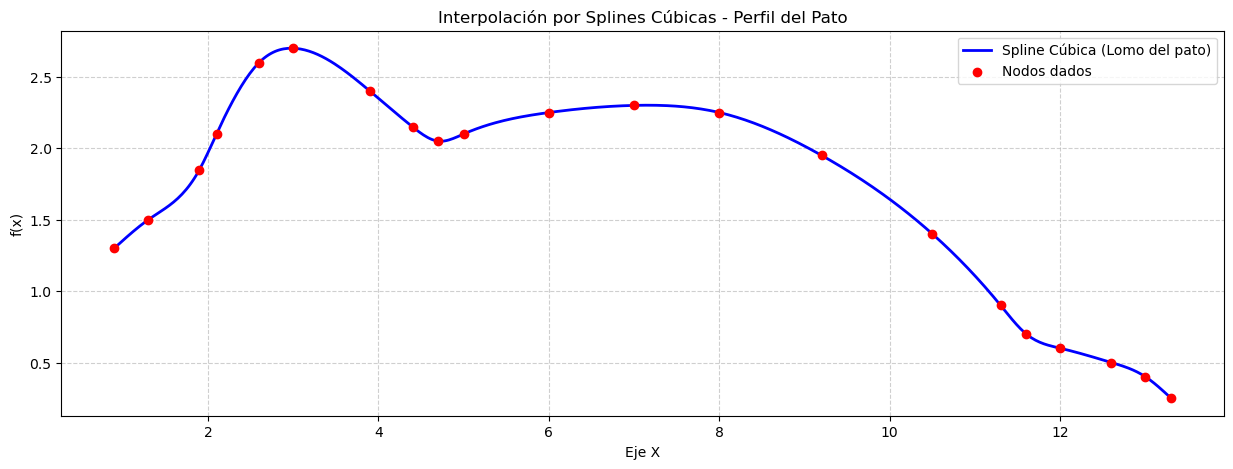

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 1. Cargamos los datos de la tabla del pato
x = np.array([0.9, 1.3, 1.9, 2.1, 2.6, 3.0, 3.9, 4.4, 4.7, 5.0, 6.0, 
              7.0, 8.0, 9.2, 10.5, 11.3, 11.6, 12.0, 12.6, 13.0, 13.3])
y = np.array([1.3, 1.5, 1.85, 2.1, 2.6, 2.7, 2.4, 2.15, 2.05, 2.1, 2.25, 
              2.3, 2.25, 1.95, 1.4, 0.9, 0.7, 0.6, 0.5, 0.4, 0.25])

# 2. Invocamos la función de Scipy para crear la Spline Cúbica
# Usamos 'natural' como condición de frontera (derivada segunda cero en los extremos)
spline_pato = CubicSpline(x, y, bc_type='natural')

# 3. Creamos un dominio con muchos puntos para que el trazado sea súper suave
x_curva = np.linspace(min(x), max(x), 500)
# Evaluamos el spline en esos nuevos puntos
y_curva = spline_pato(x_curva)

# 4. Graficamos
plt.figure(figsize=(15, 5))
plt.plot(x_curva, y_curva, label='Spline Cúbica (Lomo del pato)', color='blue', linewidth=2)
plt.scatter(x, y, color='red', label='Nodos dados', zorder=5)

plt.title('Interpolación por Splines Cúbicas - Perfil del Pato')
plt.xlabel('Eje X')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()